# Notebook 2: Modelado con Validación Segura (Pipeline + GridSearchCV)
## Proyecto Integrador — Predicción de Falla Cardíaca

**Objetivo:** Construir pipelines con múltiples clasificadores, optimizar hiperparámetros con `GridSearchCV`, y comparar modelos usando AUC y Accuracy. Exportar el mejor modelo para despliegue.

**Modelos evaluados:** SVC, LogisticRegression, RandomForestClassifier, KNeighborsClassifier, GradientBoostingClassifier

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (roc_auc_score, accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay)

import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 1. Carga y Preparación de Datos

In [ ]:
df = pd.read_csv("../heart.csv")
print(f"Shape: {df.shape}")

X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]
X_encoded = pd.get_dummies(X, drop_first=True)

# División ANTES del escalado (evitar data leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Distribución train - 0: {(y_train==0).sum()}, 1: {(y_train==1).sum()}")
print(f"Distribución test  - 0: {(y_test==0).sum()}, 1: {(y_test==1).sum()}")

Shape: (918, 12)
Train: (734, 15), Test: (184, 15)
Distribución train - 0: 298, 1: 436
Distribución test  - 0: 78, 1: 106


## 2. Función Reutilizable para Entrenamiento

In [ ]:
def train_pipeline(X_train, y_train, model, param_grid, model_name="modelo"):
    """Entrena un pipeline (MinMaxScaler + modelo) con GridSearchCV."""
    pipe = Pipeline([
        ("scaler", MinMaxScaler()),
        ("clf", model)
    ])
    grid = GridSearchCV(pipe, param_grid, cv=5, scoring="roc_auc", n_jobs=-1)
    grid.fit(X_train, y_train)
    print(f"--- {model_name} ---")
    print(f"  Mejor AUC (CV): {grid.best_score_:.3f}")
    print(f"  Mejores params: {grid.best_params_}")
    return grid

### 3.1 SVC

In [ ]:
grid_svc = train_pipeline(
    X_train, y_train,
    model=SVC(probability=True),
    param_grid={"clf__C": [0.1, 1, 10], "clf__gamma": [0.01, 0.1, 1], "clf__kernel": ["rbf"]},
    model_name="SVC"
)

--- SVC ---
  Mejor AUC (CV): 0.700
  Mejores params: {'clf__C': 10, 'clf__gamma': 0.01, 'clf__kernel': 'rbf'}


### 3.2 LogisticRegression

In [ ]:
grid_lr = train_pipeline(
    X_train, y_train,
    model=LogisticRegression(max_iter=1000),
    param_grid={"clf__C": [0.01, 0.1, 1, 10, 100]},
    model_name="LogisticRegression"
)

--- LogisticRegression ---
  Mejor AUC (CV): 0.707
  Mejores params: {'clf__C': 1}


### 3.3 RandomForest

In [ ]:
grid_rf = train_pipeline(
    X_train, y_train,
    model=RandomForestClassifier(random_state=42),
    param_grid={"clf__n_estimators": [50, 100, 200], "clf__max_depth": [5, 10, None], "clf__max_features": [1, 2, 3]},
    model_name="RandomForest"
)

--- RandomForest ---
  Mejor AUC (CV): 0.679
  Mejores params: {'clf__max_depth': 5, 'clf__max_features': 1, 'clf__n_estimators': 200}


### 3.4 KNN

In [ ]:
grid_knn = train_pipeline(
    X_train, y_train,
    model=KNeighborsClassifier(),
    param_grid={"clf__n_neighbors": [3, 5, 7, 9, 11], "clf__weights": ["uniform", "distance"]},
    model_name="KNN"
)

--- KNN ---
  Mejor AUC (CV): 0.647
  Mejores params: {'clf__n_neighbors': 7, 'clf__weights': 'distance'}


### 3.5 GradientBoosting

In [ ]:
grid_gbc = train_pipeline(
    X_train, y_train,
    model=GradientBoostingClassifier(random_state=42),
    param_grid={"clf__n_estimators": [50, 100, 200], "clf__learning_rate": [0.01, 0.1, 0.2], "clf__max_depth": [3, 5]},
    model_name="GradientBoosting"
)

--- GradientBoosting ---
  Mejor AUC (CV): 0.669
  Mejores params: {'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__n_estimators': 100}


## 4. Comparación de Modelos (Ranking)

In [ ]:
models = {
    "SVC": grid_svc, "LogisticRegression": grid_lr, "RandomForest": grid_rf,
    "KNN": grid_knn, "GradientBoosting": grid_gbc
}

results = []
for name, grid in models.items():
    y_pred = grid.predict(X_test)
    y_proba = grid.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_proba)
    acc = accuracy_score(y_test, y_pred)
    results.append({"Modelo": name, "AUC (test)": round(auc, 4),
        "Accuracy (test)": round(acc, 4), "AUC (CV)": round(grid.best_score_, 4),
        "Mejores Params": str(grid.best_params_)})

results_df = pd.DataFrame(results).sort_values("AUC (test)", ascending=False)
results_df.index = range(1, len(results_df) + 1)
results_df.index.name = "Ranking"
print("\n========== RANKING DE MODELOS ==========")
results_df


========== RANKING DE MODELOS ==========


,Modelo,AUC (test),Accuracy (test),AUC (CV),Mejores Params
Ranking,,,,,
1,RandomForest,0.7580,0.6522,0.6792,"{'clf__max_depth': 5, 'clf__max_features': 1, 'clf__n_estimators': 200}"
2,GradientBoosting,0.7548,0.6576,0.6693,"{'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__n_estimators': 100}"
3,LogisticRegression,0.7458,0.6902,0.7067,{'clf__C': 1}
4,SVC,0.7391,0.7065,0.6995,"{'clf__C': 10, 'clf__gamma': 0.01, 'clf__kernel': 'rbf'}"
5,KNN,0.6636,0.6250,0.6469,"{'clf__n_neighbors': 7, 'clf__weights': 'distance'}"


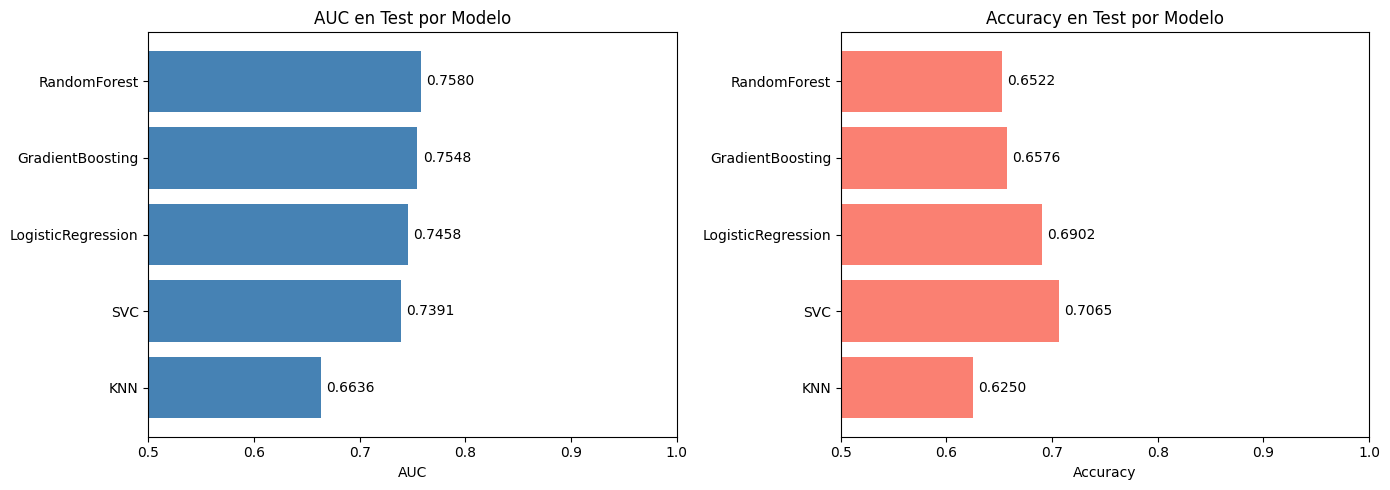

In [ ]:
# Visualización del ranking
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
results_sorted = results_df.sort_values("AUC (test)", ascending=True)
axes[0].barh(results_sorted["Modelo"], results_sorted["AUC (test)"], color="steelblue")
axes[0].set_xlabel("AUC"); axes[0].set_title("AUC en Test por Modelo"); axes[0].set_xlim(0.5, 1.0)
for i, v in enumerate(results_sorted["AUC (test)"]): axes[0].text(v + 0.005, i, f"{v:.4f}", va='center')
axes[1].barh(results_sorted["Modelo"], results_sorted["Accuracy (test)"], color="salmon")
axes[1].set_xlabel("Accuracy"); axes[1].set_title("Accuracy en Test por Modelo"); axes[1].set_xlim(0.5, 1.0)
for i, v in enumerate(results_sorted["Accuracy (test)"]): axes[1].text(v + 0.005, i, f"{v:.4f}", va='center')
plt.tight_layout()
plt.show()

## 5. Evaluación Detallada del Mejor Modelo

In [ ]:
best_name = results_df.iloc[0]["Modelo"]
best_grid = models[best_name]
y_pred_best = best_grid.predict(X_test)
y_proba_best = best_grid.predict_proba(X_test)[:, 1]

print(f"Mejor modelo: {best_name}")
print(f"Mejores parámetros: {best_grid.best_params_}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_best, target_names=["No Disease", "Disease"]))

Mejor modelo: RandomForest
Mejores parámetros: {'clf__max_depth': 5, 'clf__max_features': 1, 'clf__n_estimators': 200}

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.82      0.23      0.36        78
     Disease       0.63      0.96      0.76       106

    accuracy                           0.65       184
   macro avg       0.72      0.60      0.56       184
weighted avg       0.71      0.65      0.59       184



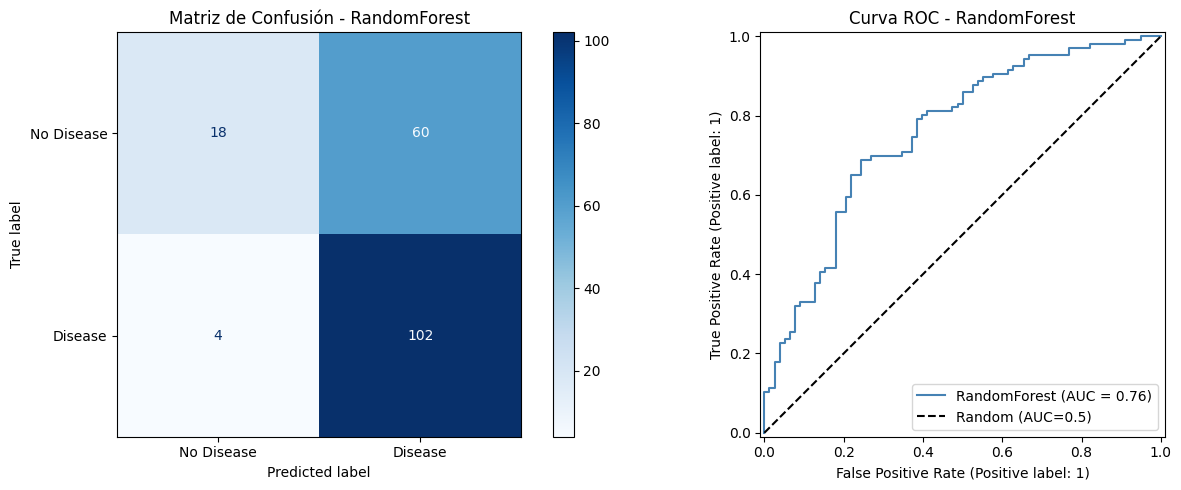

In [ ]:
# Matriz de confusión y Curva ROC
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best, display_labels=["No Disease", "Disease"], cmap="Blues", ax=axes[0])
axes[0].set_title(f"Matriz de Confusión - {best_name}")
RocCurveDisplay.from_predictions(y_test, y_proba_best, ax=axes[1], name=best_name, color="steelblue")
axes[1].plot([0, 1], [0, 1], 'k--', label="Random (AUC=0.5)")
axes[1].set_title(f"Curva ROC - {best_name}"); axes[1].legend()
plt.tight_layout()
plt.show()

## 6. Curvas ROC de Todos los Modelos

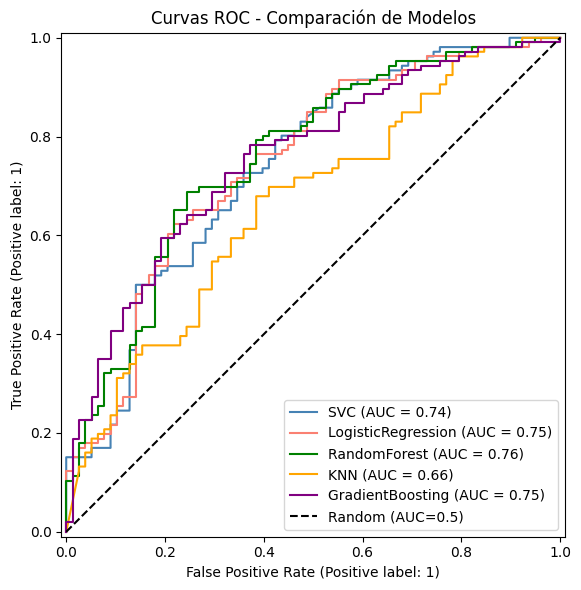

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['steelblue', 'salmon', 'green', 'orange', 'purple']
for (name, grid), color in zip(models.items(), colors):
    y_proba = grid.predict_proba(X_test)[:, 1]
    RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax, name=name, color=color)
ax.plot([0, 1], [0, 1], 'k--', label="Random (AUC=0.5)")
ax.set_title("Curvas ROC - Comparación de Modelos"); ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 7. Exportación del Mejor Modelo

In [ ]:
joblib.dump(best_grid.best_estimator_, "../app/model.joblib")
joblib.dump(best_grid.best_estimator_, "../model.joblib")
print(f"Modelo exportado: {best_name}")
print(f"Pipeline: {best_grid.best_estimator_}")

Modelo exportado: RandomForest
Pipeline: Pipeline(steps=[('scaler', MinMaxScaler()),
                ('clf',
                 RandomForestClassifier(max_depth=5, max_features=1,
                                        n_estimators=200, random_state=42))])


## 8. Conclusiones

- Se construyeron **5 pipelines** con `MinMaxScaler` + clasificador, cada uno optimizado con `GridSearchCV`.
- Se evitó data leakage al dividir los datos **antes** del escalado y usar `Pipeline`.
- Se compararon los modelos por **AUC** y **Accuracy** en el conjunto de test.
- El mejor modelo fue exportado con `joblib` para su uso en la API de predicción (FastAPI).